Training Q-Learning...
Q-Learning completed!

Training SARSA...
SARSA completed!


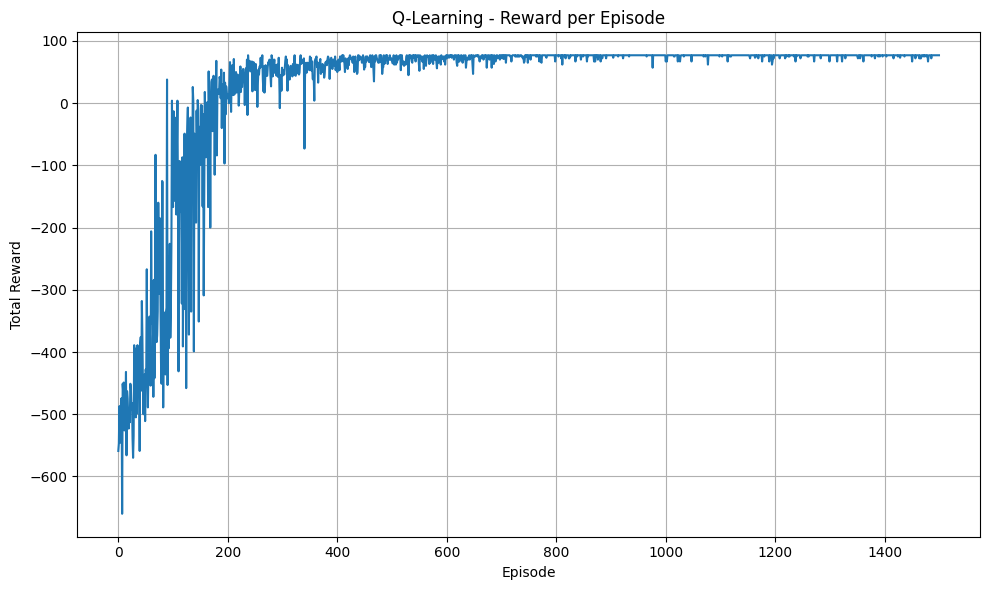

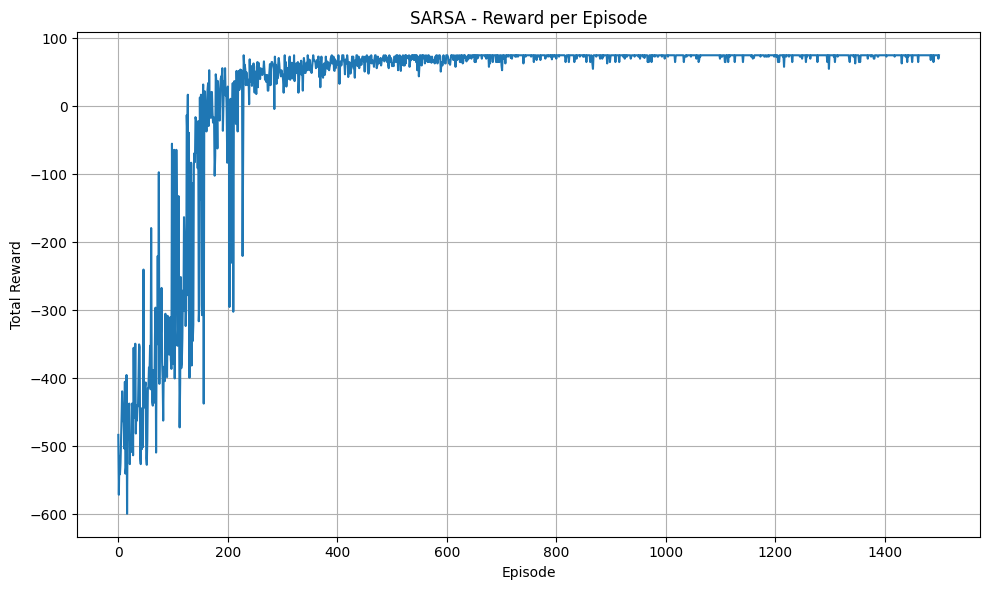

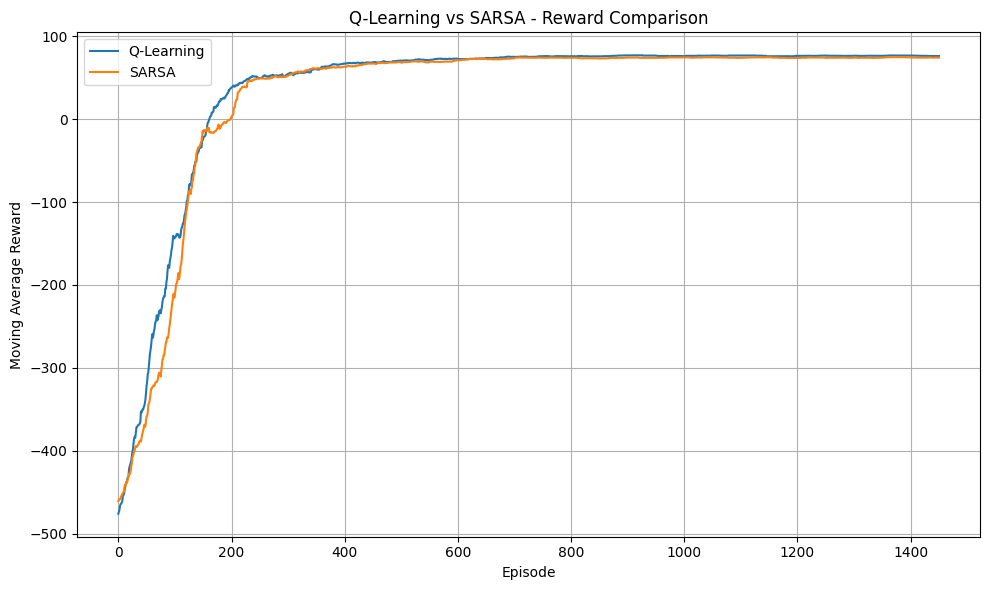

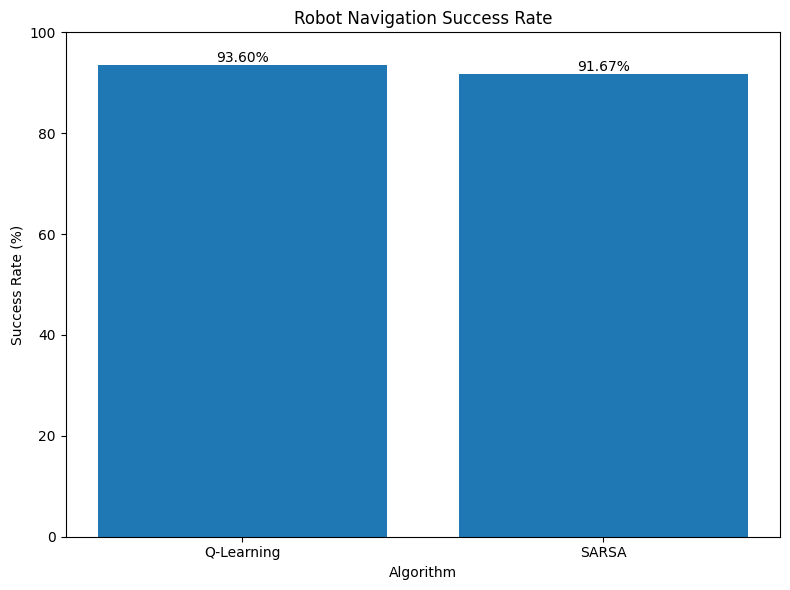

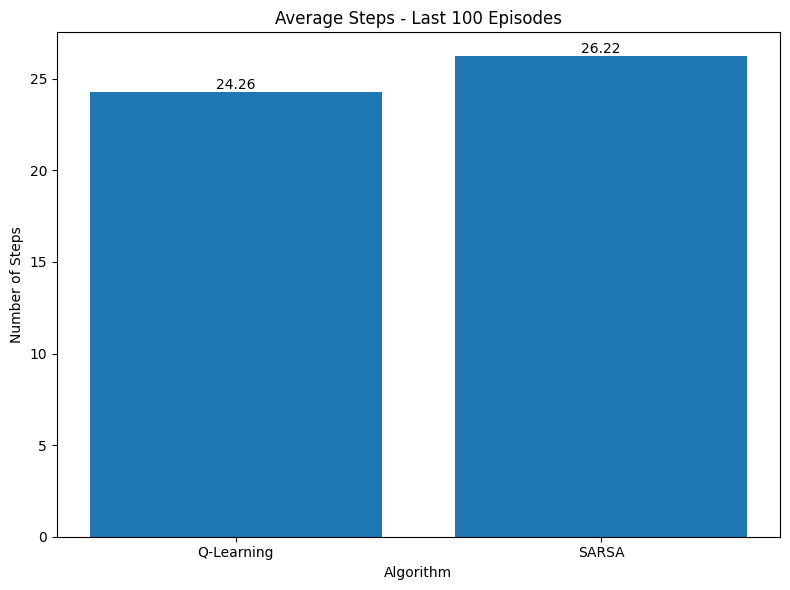

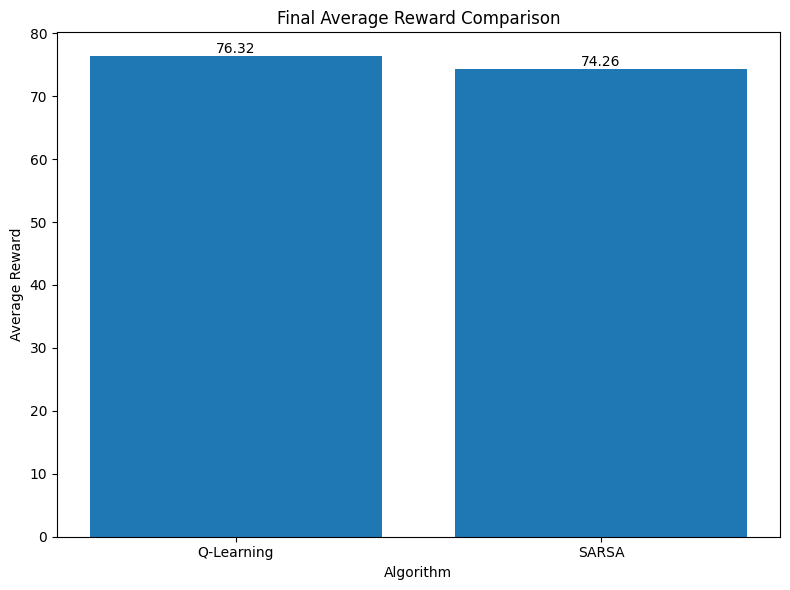

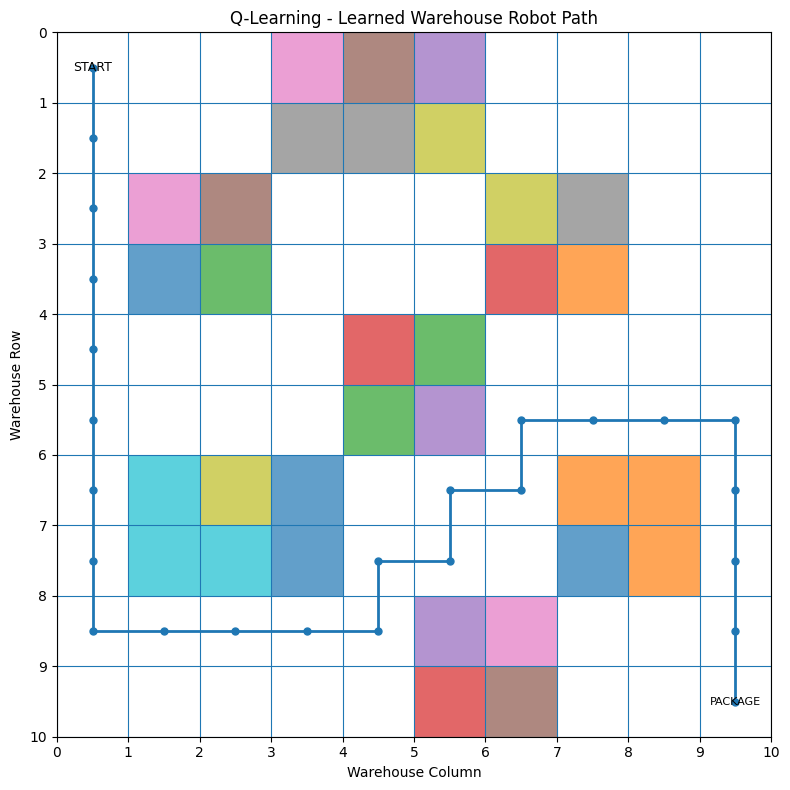

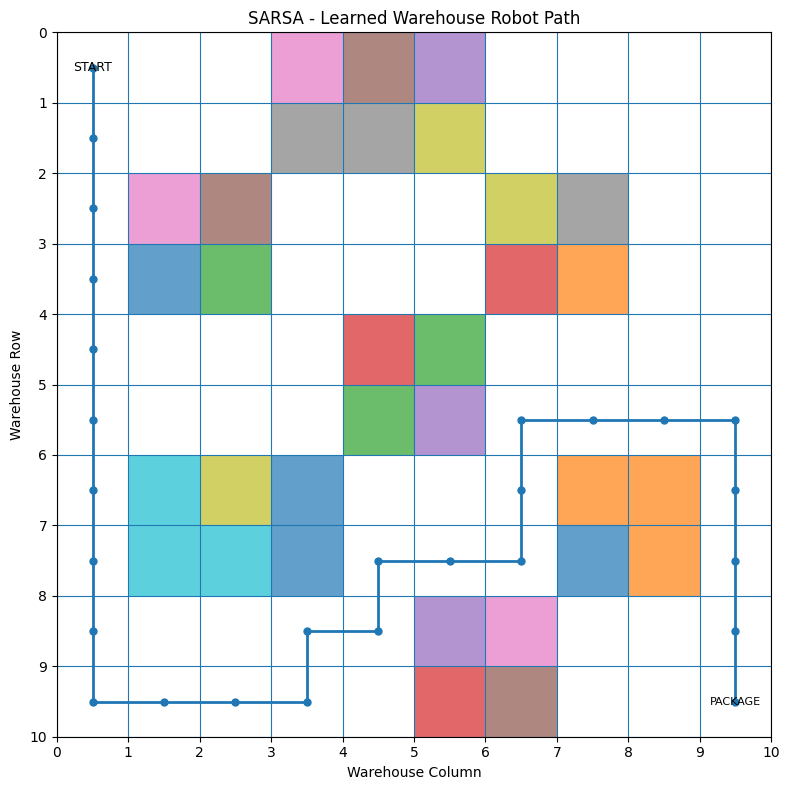



FINAL RESULTS
Q-Learning Final Average Reward : 76.32
SARSA Final Average Reward      : 74.26

Q-Learning Success Rate         : 93.60%
SARSA Success Rate              : 91.67%

Q-Learning Average Steps        : 24.26
SARSA Average Steps             : 26.22

Q-Learning Path Length          : 25
SARSA Path Length               : 27

BEST MODEL: Q-Learning


In [ ]:
# ============================================================
# SMART WAREHOUSE ROBOT NAVIGATION
# Q-LEARNING vs SARSA
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import random

# ============================================================
# 1. WAREHOUSE ENVIRONMENT
# ============================================================

ROWS = 10
COLS = 10

# Starting point / Charging Station
START = (0, 0)

# Package location
GOAL = (9, 9)

# Warehouse shelves / obstacles
OBSTACLES = {
    (0, 3), (0, 4), (0, 5),
    (1, 3), (1, 4), (1, 5),

    (2, 1), (2, 2), (2, 6), (2, 7),

    (3, 1), (3, 2), (3, 6), (3, 7),

    (4, 4), (4, 5),

    (5, 4), (5, 5),

    (6, 1), (6, 2), (6, 3),
    (6, 7), (6, 8),

    (7, 1), (7, 2), (7, 3),
    (7, 7), (7, 8),

    (8, 5), (8, 6),

    (9, 5), (9, 6)
}


# ============================================================
# ACTIONS
# ============================================================

# 0 = Up
# 1 = Down
# 2 = Left
# 3 = Right

ACTIONS = [
    (-1, 0),
    (1, 0),
    (0, -1),
    (0, 1)
]

NUM_ACTIONS = 4


# ============================================================
# STATE LIST
# ============================================================

states = [
    (r, c)
    for r in range(ROWS)
    for c in range(COLS)
]

state_to_index = {
    state: i
    for i, state in enumerate(states)
}

NUM_STATES = len(states)


# ============================================================
# 2. ENVIRONMENT STEP
# ============================================================

def step(state, action):

    row, col = state

    dr, dc = ACTIONS[action]

    new_row = row + dr
    new_col = col + dc

    new_state = (
        new_row,
        new_col
    )

    # Outside warehouse
    if (
        new_row < 0
        or new_row >= ROWS
        or new_col < 0
        or new_col >= COLS
    ):

        return state, -5, False


    # Shelf / obstacle
    if new_state in OBSTACLES:

        return state, -10, False


    # Package found
    if new_state == GOAL:

        return new_state, 100, True


    # Normal movement
    return new_state, -1, False


# ============================================================
# 3. PARAMETERS
# ============================================================

EPISODES = 1500

MAX_STEPS = 150

LEARNING_RATE = 0.1

DISCOUNT_FACTOR = 0.95

EPSILON_START = 1.0

EPSILON_MIN = 0.01

EPSILON_DECAY = 0.995


# ============================================================
# 4. EPSILON GREEDY
# ============================================================

def choose_action(
    q_table,
    state,
    epsilon
):

    state_index = state_to_index[state]

    # Exploration
    if random.random() < epsilon:

        return random.randint(
            0,
            NUM_ACTIONS - 1
        )

    # Exploitation
    return np.argmax(
        q_table[state_index]
    )


# ============================================================
# 5. Q-LEARNING
# ============================================================

def train_q_learning():

    q_table = np.zeros(
        (
            NUM_STATES,
            NUM_ACTIONS
        )
    )

    rewards = []

    steps_history = []

    success_history = []

    epsilon = EPSILON_START


    for episode in range(EPISODES):

        state = START

        total_reward = 0

        success = 0

        steps_used = 0


        for step_count in range(MAX_STEPS):

            steps_used += 1


            # Choose action
            action = choose_action(
                q_table,
                state,
                epsilon
            )


            # Environment
            next_state, reward, done = step(
                state,
                action
            )


            state_index = state_to_index[state]

            next_state_index = state_to_index[next_state]


            # =================================================
            # Q-LEARNING UPDATE
            # =================================================

            best_next_value = np.max(
                q_table[next_state_index]
            )


            target = (
                reward
                +
                DISCOUNT_FACTOR
                * best_next_value
            )


            q_table[
                state_index,
                action
            ] += LEARNING_RATE * (

                target
                -
                q_table[
                    state_index,
                    action
                ]

            )


            state = next_state

            total_reward += reward


            if done:

                success = 1

                break


        rewards.append(total_reward)

        steps_history.append(steps_used)

        success_history.append(success)


        # Reduce exploration
        epsilon = max(
            EPSILON_MIN,
            epsilon * EPSILON_DECAY
        )


    return (
        q_table,
        rewards,
        steps_history,
        success_history
    )


# ============================================================
# 6. SARSA
# ============================================================

def train_sarsa():

    q_table = np.zeros(
        (
            NUM_STATES,
            NUM_ACTIONS
        )
    )

    rewards = []

    steps_history = []

    success_history = []

    epsilon = EPSILON_START


    for episode in range(EPISODES):

        state = START

        total_reward = 0

        success = 0

        steps_used = 0


        # First action
        action = choose_action(
            q_table,
            state,
            epsilon
        )


        for step_count in range(MAX_STEPS):

            steps_used += 1


            # Environment
            next_state, reward, done = step(
                state,
                action
            )


            state_index = state_to_index[state]

            next_state_index = state_to_index[next_state]


            # =================================================
            # SARSA UPDATE
            # =================================================

            if done:

                target = reward

            else:

                # Choose next action
                next_action = choose_action(
                    q_table,
                    next_state,
                    epsilon
                )


                target = (
                    reward
                    +
                    DISCOUNT_FACTOR
                    *
                    q_table[
                        next_state_index,
                        next_action
                    ]
                )


            q_table[
                state_index,
                action
            ] += LEARNING_RATE * (

                target
                -
                q_table[
                    state_index,
                    action
                ]

            )


            state = next_state

            total_reward += reward


            if done:

                success = 1

                break


            # Next action
            action = next_action


        rewards.append(total_reward)

        steps_history.append(steps_used)

        success_history.append(success)


        # Reduce exploration
        epsilon = max(
            EPSILON_MIN,
            epsilon * EPSILON_DECAY
        )


    return (
        q_table,
        rewards,
        steps_history,
        success_history
    )


# ============================================================
# 7. TRAIN BOTH MODELS
# ============================================================

print("=" * 60)

print("Training Q-Learning...")

q_table, q_rewards, q_steps, q_success = (
    train_q_learning()
)

print("Q-Learning completed!")


print()

print("Training SARSA...")

sarsa_table, sarsa_rewards, sarsa_steps, sarsa_success = (
    train_sarsa()
)

print("SARSA completed!")

print("=" * 60)


# ============================================================
# 8. MOVING AVERAGE
# ============================================================

def moving_average(
    values,
    window=50
):

    return np.convolve(
        values,
        np.ones(window) / window,
        mode="valid"
    )


q_reward_avg = moving_average(
    q_rewards
)

sarsa_reward_avg = moving_average(
    sarsa_rewards
)


# ============================================================
# GRAPH 1
# Q-LEARNING REWARD
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    q_rewards
)

plt.title(
    "Q-Learning - Reward per Episode"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Total Reward"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 2
# SARSA REWARD
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    sarsa_rewards
)

plt.title(
    "SARSA - Reward per Episode"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Total Reward"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 3
# REWARD COMPARISON
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    q_reward_avg,
    label="Q-Learning"
)

plt.plot(
    sarsa_reward_avg,
    label="SARSA"
)

plt.title(
    "Q-Learning vs SARSA - Reward Comparison"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Moving Average Reward"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 4
# SUCCESS RATE
# ============================================================

q_success_rate = (
    np.mean(q_success) * 100
)

sarsa_success_rate = (
    np.mean(sarsa_success) * 100
)


models = [
    "Q-Learning",
    "SARSA"
]

success_rates = [
    q_success_rate,
    sarsa_success_rate
]


plt.figure(
    figsize=(8, 6)
)

bars = plt.bar(
    models,
    success_rates
)

plt.title(
    "Robot Navigation Success Rate"
)

plt.xlabel(
    "Algorithm"
)

plt.ylabel(
    "Success Rate (%)"
)

plt.ylim(
    0,
    100
)


for bar, value in zip(
    bars,
    success_rates
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 5
# AVERAGE STEPS
# ============================================================

q_avg_steps = np.mean(
    q_steps[-100:]
)

sarsa_avg_steps = np.mean(
    sarsa_steps[-100:]
)


plt.figure(
    figsize=(8, 6)
)

bars = plt.bar(
    models,
    [
        q_avg_steps,
        sarsa_avg_steps
    ]
)

plt.title(
    "Average Steps - Last 100 Episodes"
)

plt.xlabel(
    "Algorithm"
)

plt.ylabel(
    "Number of Steps"
)


for bar, value in zip(
    bars,
    [
        q_avg_steps,
        sarsa_avg_steps
    ]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 6
# FINAL REWARD COMPARISON
# ============================================================

q_final_reward = np.mean(
    q_rewards[-100:]
)

sarsa_final_reward = np.mean(
    sarsa_rewards[-100:]
)


plt.figure(
    figsize=(8, 6)
)

bars = plt.bar(
    models,
    [
        q_final_reward,
        sarsa_final_reward
    ]
)

plt.title(
    "Final Average Reward Comparison"
)

plt.xlabel(
    "Algorithm"
)

plt.ylabel(
    "Average Reward"
)


for bar, value in zip(
    bars,
    [
        q_final_reward,
        sarsa_final_reward
    ]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()


# ============================================================
# 9. GET LEARNED PATH
# ============================================================

def get_best_path(
    q_table
):

    state = START

    path = [state]

    visited = set()

    for _ in range(MAX_STEPS):

        if state == GOAL:

            break


        if state in visited:

            break


        visited.add(state)


        state_index = state_to_index[state]


        action = np.argmax(
            q_table[state_index]
        )


        next_state, reward, done = step(
            state,
            action
        )


        # Cannot move
        if next_state == state:

            break


        path.append(
            next_state
        )

        state = next_state


        if done:

            break


    return path


q_path = get_best_path(
    q_table
)

sarsa_path = get_best_path(
    sarsa_table
)


# ============================================================
# 10. WAREHOUSE MAP FUNCTION
# ============================================================

def draw_warehouse(
    path,
    title
):

    plt.figure(
        figsize=(8, 8)
    )


    # Grid
    for x in range(COLS + 1):

        plt.axvline(
            x,
            linewidth=0.8
        )


    for y in range(ROWS + 1):

        plt.axhline(
            y,
            linewidth=0.8
        )


    # Obstacles
    for obstacle in OBSTACLES:

        r, c = obstacle

        plt.fill_between(
            [c, c + 1],
            r,
            r + 1,
            alpha=0.7
        )


    # Learned path
    path_x = [
        c + 0.5
        for r, c in path
    ]

    path_y = [
        r + 0.5
        for r, c in path
    ]


    plt.plot(
        path_x,
        path_y,
        marker="o",
        linewidth=2,
        markersize=5
    )


    # Start
    plt.text(
        START[1] + 0.5,
        START[0] + 0.5,
        "START",
        ha="center",
        va="center",
        fontsize=9
    )


    # Goal
    plt.text(
        GOAL[1] + 0.5,
        GOAL[0] + 0.5,
        "PACKAGE",
        ha="center",
        va="center",
        fontsize=8
    )


    plt.xlim(
        0,
        COLS
    )

    plt.ylim(
        ROWS,
        0
    )


    plt.xticks(
        range(COLS + 1)
    )

    plt.yticks(
        range(ROWS + 1)
    )


    plt.title(
        title
    )

    plt.xlabel(
        "Warehouse Column"
    )

    plt.ylabel(
        "Warehouse Row"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# GRAPH 7
# Q-LEARNING WAREHOUSE PATH
# ============================================================

draw_warehouse(
    q_path,
    "Q-Learning - Learned Warehouse Robot Path"
)


# ============================================================
# GRAPH 8
# SARSA WAREHOUSE PATH
# ============================================================

draw_warehouse(
    sarsa_path,
    "SARSA - Learned Warehouse Robot Path"
)


# ============================================================
# 11. FINAL RESULTS
# ============================================================

print("\n")
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(
    f"Q-Learning Final Average Reward : "
    f"{q_final_reward:.2f}"
)

print(
    f"SARSA Final Average Reward      : "
    f"{sarsa_final_reward:.2f}"
)

print()

print(
    f"Q-Learning Success Rate         : "
    f"{q_success_rate:.2f}%"
)

print(
    f"SARSA Success Rate              : "
    f"{sarsa_success_rate:.2f}%"
)

print()

print(
    f"Q-Learning Average Steps        : "
    f"{q_avg_steps:.2f}"
)

print(
    f"SARSA Average Steps             : "
    f"{sarsa_avg_steps:.2f}"
)

print()

print(
    f"Q-Learning Path Length          : "
    f"{len(q_path)}"
)

print(
    f"SARSA Path Length               : "
    f"{len(sarsa_path)}"
)

print()


# ============================================================
# 12. BEST MODEL
# ============================================================

if q_success_rate > sarsa_success_rate:

    print(
        "BEST MODEL: Q-Learning"
    )

elif sarsa_success_rate > q_success_rate:

    print(
        "BEST MODEL: SARSA"
    )

else:

    if q_final_reward > sarsa_final_reward:

        print(
            "BEST MODEL: Q-Learning"
        )

    elif sarsa_final_reward > q_final_reward:

        print(
            "BEST MODEL: SARSA"
        )

    else:

        print(
            "Both models have similar performance."
        )


print("=" * 60)